# **FashionMNIST**

Requried packages for the example code.






In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
import torchvision.transforms as transforms # for data preprocessing
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary

In [2]:
train_dataset = torchvision.datasets.FashionMNIST('./data', download=True, transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST('./data', download=True, train=False, transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.66MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 152kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 2.87MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 23.0MB/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



If the download parameter is set to True, it will check if the dataset is available and then download it.
The transform parameter is used to convert the image into a tensor with values ranging from 0 to 1.

The following is for loading data into memory.






In [3]:
batch_size = 1000
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size)

This is for loading data in batches during training. It loads a batch of 100 images at a time. The default value is 200. Additionally, by default, the data is shuffled before being divided into batches.

I will now display on the screen what the actual data looks like.






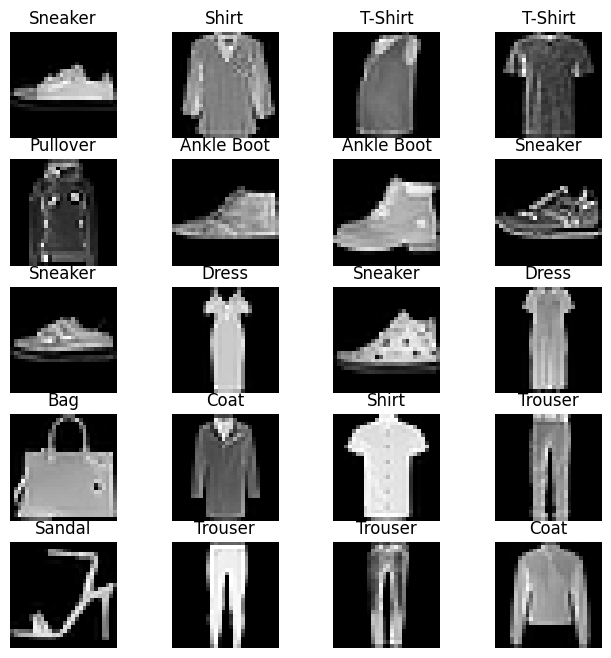

In [4]:
labels_map = {0:'T-Shirt', 1:'Trouser', 2:'Pullover', 3:'Dress', 4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker', 8:'Bag', 9:'Ankle Boot'} # 10 classes
fig = plt.figure(figsize=(8,8))
columns = 4
rows = 5
for i in range(1, columns*rows + 1):
    rand_idx = np.random.randint(len(train_dataset))
    img = train_dataset[rand_idx][0][0,:,:] # extract image data [image index][x][image]
    fig.add_subplot(rows, columns, i)
    plt.title(labels_map[train_dataset[rand_idx][1]]) # train_dataset[rand_idx][1] is class number (0~9)
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()

The following defines a neural network model.






In [ ]:
class FashionDNN1(nn.Module):
    def __init__(self):
        super(FashionDNN1, self).__init__()
        self.fc1 = nn.Linear(in_features=784, out_features=256)
        self.drop = nn.Dropout(0.25) # Please see Lecutre 16 or you can comment this line out
        self.fc2 = nn.Linear(in_features=256, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=10)
    def forward(self, input_data):
        out = input_data.view(-1, 784)
        out = F.relu(self.fc1(out))
        out = self.drop(out)
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return out

The nn.Linear() function represents a fully connected layer in PyTorch. It defines the number of input nodes from the previous layer and the number of nodes in the added layer using the in_features and out_features arguments. In this example, there are 784 input nodes in the input layer, and the first hidden layer has 256 nodes.






The forward function defines the process of forward propagation. The input_data.view(-1, 784) is used to convert the FashionMNIST data, which is in the form of images, into a single long 1-dimensional tensor (vector). This conversion is necessary to match the input shape expected by the neural network model.

The definition of this neural network model can also be done using nn.Sequential() as in other provided examples.

In [ ]:
class FashionDNN2(nn.Module):
    def __init__(self):
        super(FashionDNN2, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Linear(in_features=784, out_features=256),
            nn.ReLU(),
            nn.Dropout(0.25)
        )
        self.layer2 = nn.Sequential(
            nn.Linear(in_features=256, out_features=128)
        )
        self.layer3 = nn.Sequential(
            nn.Linear(in_features=128, out_features=10)
        )
    def forward(self, input_data):
        out = input_data.view(-1, 784)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        return out

Both approaches are acceptable at this point. Please feel free to choose the method that you prefer.

Now, let's define a CNN model


In [5]:
class FashionDNN3(nn.Module):
    def __init__(self):
        super(FashionDNN3, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer3 = nn.Sequential(
            nn.Linear(in_features=64*6*6, out_features=600),
            nn.Linear(600, 120),
            nn.Linear(120, 10)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        x = self.layer3(x)
        return x

model = FashionDNN3()
#summary(model, (1, 28, 28))

Afterward, we proceed to specify the loss function, learning rate, and optimizer, crucial components for training the model.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FashionDNN3().to(device)


# loss and optimizer
from torch.optim import optimizer
import torch
import numpy as np

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# train
n_epoch = 10
for epoch in range(1, n_epoch+1):
    train_losses = []
    train_acc = []
    for idx, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        train_losses.append(loss.item())
        train_acc.append( (torch.max(pred, 1)[1] == y).sum()/batch_size )
        loss.backward()
        optimizer.step()
    print('epoch: {}, loss:{}, acc:{}'.format(epoch, sum(train_losses)/(idx+1), sum(train_acc)/(idx+1) ))

epoch: 1, loss:20.89529679218928, acc:0.53041672706604
epoch: 2, loss:0.6656394958496094, acc:0.7817332744598389
epoch: 3, loss:0.5028438732028008, acc:0.8185501098632812
epoch: 4, loss:0.442521304388841, acc:0.8407834768295288
epoch: 5, loss:0.39704306423664093, acc:0.8568000197410583
epoch: 6, loss:0.36649344364802044, acc:0.8673000931739807
epoch: 7, loss:0.3411669611930847, acc:0.8760834336280823
epoch: 8, loss:0.32443743844827017, acc:0.8826833367347717
epoch: 9, loss:0.307438799738884, acc:0.887983500957489
epoch: 10, loss:0.2951260375479857, acc:0.8925501704216003


In [ ]:
test_acc = []
for i, (x, y) in enumerate(test_loader):
    x = x.to(device)
    y = y.to(device)
    test_pred = model(x)
    test_acc.append((torch.max(test_pred, 1)[1] == y).sum()/batch_size)
print('test acc:{}'.format(sum(test_acc)/(len(test_acc) )) )

test acc:0.8949000239372253
